In [3]:
import time

In [1]:
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Key parameters
IMAGE_DIMS = (224, 224)  # Image dimensions (width, height)
dataset_dir = "C:/Users/Souma Chakraborty/OneDrive/Desktop/ML_RESEARCH/Fruit And Vegetable Diseases Dataset"
ALLOWED_CLASSES = {"Apple_healthy_augmented", "Apple_rotten_augmented"}

# Custom Dataset class
class FruitDataset(Dataset):
    def __init__(self, imagePaths, labels, transform=None):
        self.imagePaths = imagePaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imagePaths)

    def __getitem__(self, idx):
        imagePath = self.imagePaths[idx]
        image = cv2.imread(imagePath)
        if image is None:
            raise ValueError(f"Failed to load image: {imagePath}")
        image = cv2.resize(image, IMAGE_DIMS)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype("float32") / 255.0
        if self.transform:
            image = self.transform(image)
        else:
            # Convert HWC to CHW tensor
            image = torch.from_numpy(image.transpose(2, 0, 1))
        label = self.labels[idx]
        return image, label

def load_data():
    data = []
    labels = []
    imagePaths = list(paths.list_images(dataset_dir))
    print(f"Found {len(imagePaths)} images in total.")
    for imagePath in imagePaths:
        label = imagePath.split(os.path.sep)[-2]
        if label not in ALLOWED_CLASSES:
            continue
        image = cv2.imread(imagePath)
        if image is None:
            print(f"Failed to load image: {imagePath}")
            continue
        data.append(imagePath)
        labels.append(label)
    print(f"\nProcessed {len(data)} images")
    print(f"Unique labels found: {set(labels)}")
    if len(data) == 0:
        raise ValueError("No images were processed. Check your dataset directory and paths.")
    # Encode labels
    le = LabelEncoder()
    encoded_labels = le.fit_transform(labels)
    # Split data into training and testing sets
    (trainPaths, testPaths, trainLabels, testLabels) = train_test_split(
        data, encoded_labels, test_size=0.20, random_state=42)
    return trainPaths, testPaths, trainLabels, testLabels, le

# Load the data
trainPaths, testPaths, trainLabels, testLabels, le = load_data()

# Optional: define additional transforms if desired
transform = transforms.Compose([
    transforms.ToTensor()  # Converts image from HWC [0,1] to CHW tensor [0,1]
])

# Create Dataset objects
trainDataset = FruitDataset(trainPaths, trainLabels, transform=None)
testDataset = FruitDataset(testPaths, testLabels, transform=None)

# Create DataLoaders
BS = 32  # Batch size
trainLoader = DataLoader(trainDataset, batch_size=BS, shuffle=True, num_workers=0, drop_last=True)
testLoader = DataLoader(testDataset, batch_size=BS, shuffle=False, num_workers=0, drop_last=True)


Found 7579 images in total.

Processed 5362 images
Unique labels found: {'Apple_rotten_augmented', 'Apple_healthy_augmented'}


In [ ]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the CNN model with quantization support
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes):
        super(EnhancedCNN, self).__init__()
        # Quantization stubs
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()
        
        self.features = nn.Sequential(
            # Block 1: Conv -> BatchNorm -> ReLU -> MaxPool
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            # Block 4: Additional feature extraction block
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )
        # Calculate flattened feature size; pooling factor = 16 for 224x224 images.
        self.flattened_size = 128 * (IMAGE_DIMS[0] // 16) * (IMAGE_DIMS[1] // 16)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        x = self.classifier(x)
        x = self.dequant(x)
        return x

    def fuse_model(self):
        # Fuse modules in each block to improve quantization performance
        torch.quantization.fuse_modules(self.features, [['0', '1', '2']], inplace=True)
        torch.quantization.fuse_modules(self.features, [['4', '5', '6']], inplace=True)
        torch.quantization.fuse_modules(self.features, [['8', '9', '10']], inplace=True)
        torch.quantization.fuse_modules(self.features, [['12', '13', '14']], inplace=True)

# Instantiate model, loss, and optimizer
model = EnhancedCNN(num_classes=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(model)
print(f"Training on device: {device}")

# Training loop
EPOCHS = 20
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("[INFO] Training enhanced CNN model...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    for images, labels in tqdm(trainLoader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total += images.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())
    
    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)
            val_total += images.size(0)
    val_loss = val_running_loss / val_total
    val_acc = val_running_corrects.double() / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.item())
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Train loss {epoch_loss:.4f}, Train acc {epoch_acc:.4f}, Val loss {val_loss:.4f}, Val acc {val_acc:.4f}")

# Define evaluation function to benchmark inference and accuracy
def evaluate(model, dataloader, device_eval):
    model.to(device_eval)
    model.eval()
    all_preds = []
    all_labels = []
    total_time = 0.0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device_eval)
            start = time.time()
            outputs = model(images)
            end = time.time()
            total_time += (end - start)
            total_samples += images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    avg_inference_time = (total_time / total_samples) * 1000  # ms per image
    return accuracy, avg_inference_time




EnhancedCNN(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

Epoch 1/20: 100%|██████████| 134/134 [03:16<00:00,  1.47s/it]


Epoch 1/20: Train loss 0.2491, Train acc 0.8969, Val loss 0.1645, Val acc 0.9318


Epoch 2/20: 100%|██████████| 134/134 [03:43<00:00,  1.67s/it]


Epoch 2/20: Train loss 0.1251, Train acc 0.9585, Val loss 0.1302, Val acc 0.9564


...

Epoch 19/20: 100%|██████████| 134/134 [03:19<00:00,  1.49s/it]


Epoch 19/20: Train loss 0.0074, Train acc 0.9991, Val loss 0.0529, Val acc 0.9858


Epoch 20/20: 100%|██████████| 134/134 [03:19<00:00,  1.49s/it]


Epoch 20/20: Train loss 0.0162, Train acc 0.9953, Val loss 0.0654, Val acc 0.9744


NameError: name 'time' is not defined

In [5]:
fp32_accuracy, fp32_inference_time = evaluate(model, testLoader, device)
print(f"FP32 model - Accuracy: {fp32_accuracy:.4f}, Inference Time: {fp32_inference_time:.2f} ms/image")

FP32 model - Accuracy: 0.9744, Inference Time: 12.00 ms/image


[INFO] Generating training history plot...


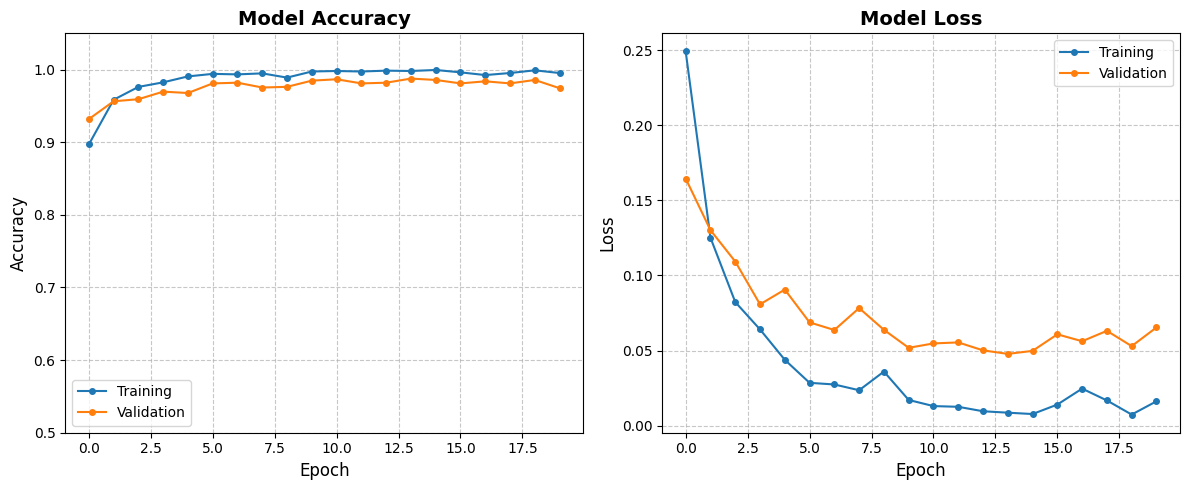

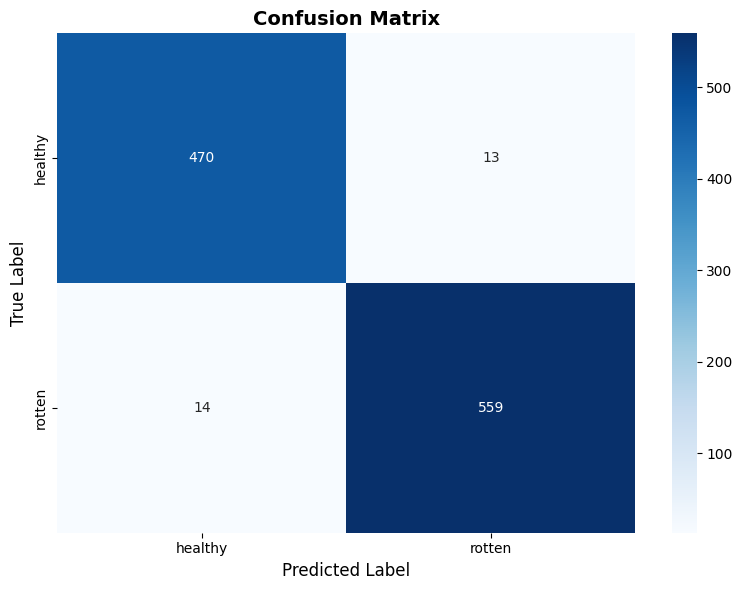

Confusion Matrix Accuracy: 0.9744
[INFO] Classification Report:
              precision    recall  f1-score   support

     healthy       0.97      0.97      0.97       483
      rotten       0.98      0.98      0.98       573

    accuracy                           0.97      1056
   macro avg       0.97      0.97      0.97      1056
weighted avg       0.97      0.97      0.97      1056

[INFO] Generating model performance metrics...


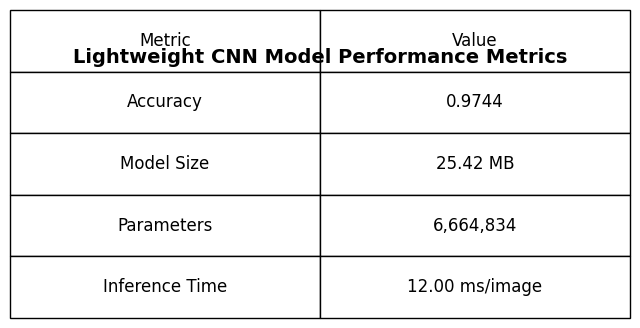

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Compute predictions on the test set and collect ground truth labels
# (This block assumes you've already run the evaluation block that populates all_preds and all_labels)
y_true = all_labels  # from evaluation
y_pred = all_preds

# Plot training history
def plot_training_history(train_losses, val_losses, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_acc, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_acc, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim([0.5, 1.05])
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_losses, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

print("[INFO] Generating training history plot...")
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    accuracy = np.trace(cm) / np.sum(cm)
    return accuracy

# Replace long class names with simplified ones ("healthy" and "rotten")
simple_class_names = [name.replace("Apple_healthy_augmented", "healthy").replace("Apple_rotten_augmented", "rotten") for name in le.classes_]

cm_accuracy = plot_confusion_matrix(y_true, y_pred, simple_class_names)
print(f"Confusion Matrix Accuracy: {cm_accuracy:.4f}")

# Print detailed classification report including precision, recall, and F1 score
print("[INFO] Classification Report:")
print(classification_report(y_true, y_pred, target_names=simple_class_names))

def create_model_performance_metrics(model, test_accuracy, inference_time):
    total_params = sum(p.numel() for p in model.parameters())
    model_size_mb = total_params * 4 / (1024 * 1024)  # 4 bytes per parameter
    metrics = {
        'Metric': ['Accuracy', 'Model Size', 'Parameters', 'Inference Time'],
        'Value': [f'{test_accuracy:.4f}', f'{model_size_mb:.2f} MB', f'{total_params:,}', f'{inference_time:.2f} ms/image']
    }
    metrics_df = pd.DataFrame(metrics)
    plt.figure(figsize=(8, 4))
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(cellText=metrics_df.values,
                      colLabels=metrics_df.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    plt.title('Lightweight CNN Model Performance Metrics', fontsize=14, fontweight='bold', y=0.8)
    plt.show()
    return metrics_df

print("[INFO] Generating model performance metrics...")
metrics_df = create_model_performance_metrics(model, fp32_accuracy, fp32_inference_time)


In [11]:
import torch.quantization
import copy

# Save the original FP32 model for reference
torch.save(model.state_dict(), "enhanced_cnn_fp32.pth")
print("Saved FP32 model.")

# Remove Dropout and BatchNorm1d for quantization compatibility
def replace_modules(module, module_type, replacement):
    for name, child in module.named_children():
        if isinstance(child, module_type):
            setattr(module, name, replacement)
        else:
            replace_modules(child, module_type, replacement)

replace_modules(model, nn.Dropout, nn.Identity())
replace_modules(model, nn.BatchNorm1d, nn.Identity())

# Create a deep copy for quantization and move to CPU (quantization is performed on CPU)
model_int8 = copy.deepcopy(model).to('cpu')
model_int8.eval()

# Fuse layers for quantization (using the provided fuse_model method)
model_int8.fuse_model()

# Set quantization configuration and prepare for calibration
model_int8.qconfig = torch.quantization.get_default_qconfig('fbgemm')
print("Quantization configuration:", model_int8.qconfig)
torch.quantization.prepare(model_int8, inplace=True)

# Calibration: run one batch from trainLoader
with torch.no_grad():
    for images, _ in trainLoader:
        model_int8(images.cpu())
        break

# Convert to quantized model
torch.quantization.convert(model_int8, inplace=True)
print("Quantized model created.")

# Save the quantized model
torch.save(model_int8.state_dict(), "enhanced_cnn_int8.pth")
print("Saved quantized (INT8) model.")

# Evaluate the quantized model on CPU
int8_accuracy, int8_inference_time = evaluate(model_int8, testLoader, 'cpu')
print(f"Quantized model - Accuracy: {int8_accuracy:.4f}, Inference Time: {int8_inference_time:.2f} ms/image")


Saved FP32 model.
Quantization configuration: QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})


c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Quantized model created.
Saved quantized (INT8) model.
Quantized model - Accuracy: 0.9659, Inference Time: 3.86 ms/image


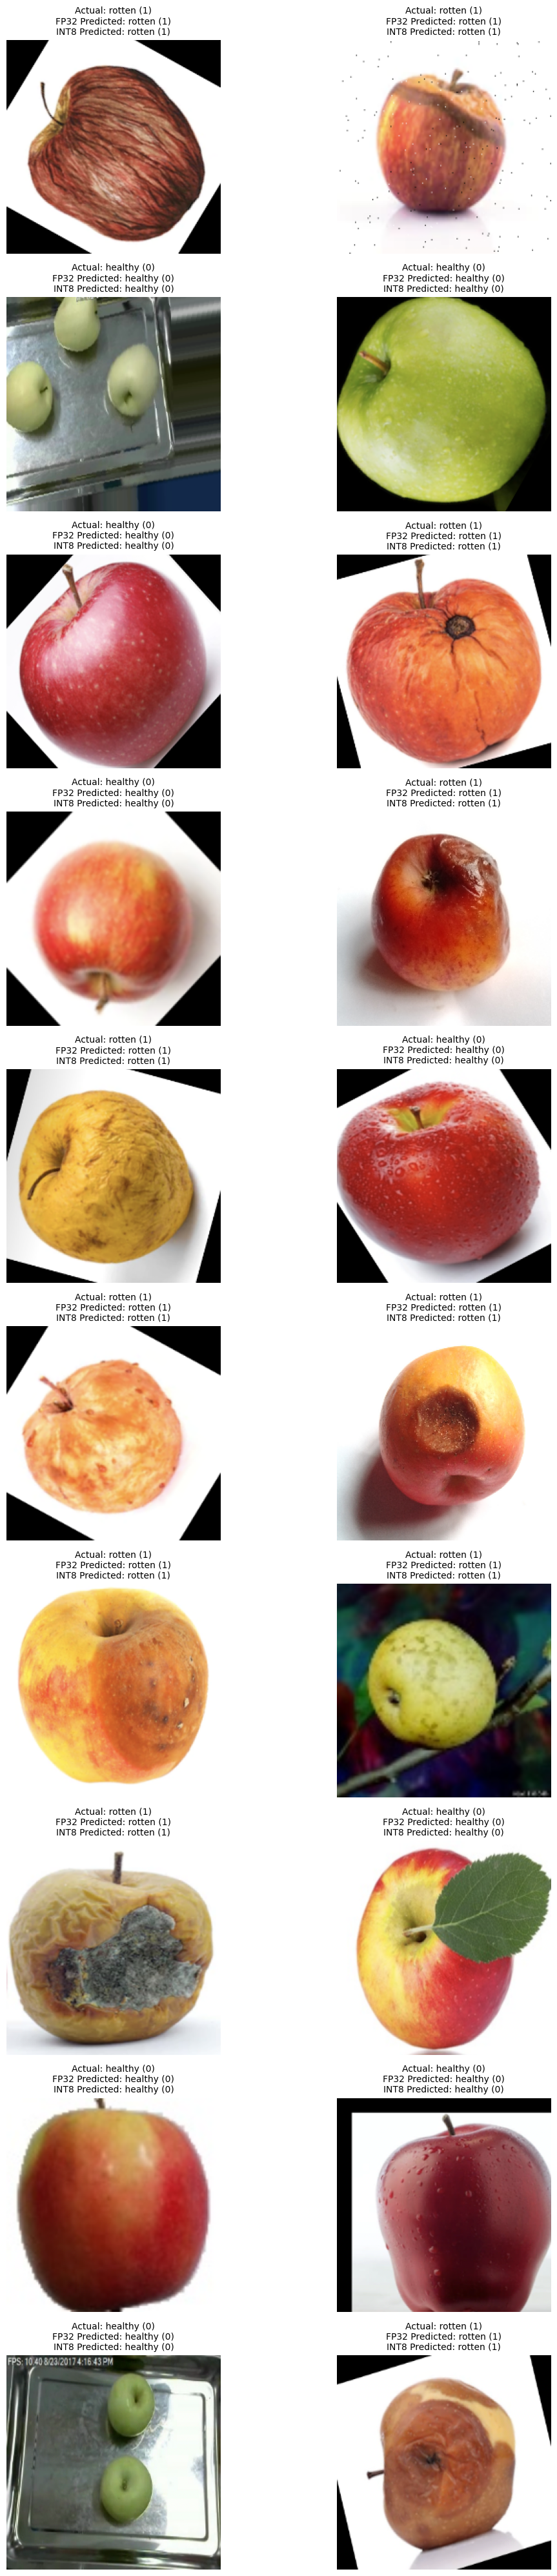

In [28]:
import random
import torch
import matplotlib.pyplot as plt

# Set number of samples to visualize
num_samples = 20  # Increase this number to see more images

# Randomly select indices from the test dataset
indices = random.sample(range(len(testDataset)), num_samples)

# Ensure both models are in evaluation mode
model.eval()       # Full (FP32) model on device (e.g., GPU)
model_int8.eval()  # Quantized model on CPU

# Prepare lists to store images and titles
images_list = []
titles_list = []

for idx in indices:
    sample_img, sample_lbl = testDataset[idx]
    input_tensor = sample_img.unsqueeze(0)  # add batch dimension

    # --- FP32 (full) model prediction ---
    with torch.no_grad():
        output_fp32 = model(input_tensor.to(device))
        _, pred_fp32 = torch.max(output_fp32, 1)
    actual_binary = sample_lbl  # actual encoded label (0 or 1)
    predicted_binary_fp32 = pred_fp32.item()  # FP32 model predicted label

    actual_class = le.inverse_transform([actual_binary])[0]
    predicted_class_fp32 = le.inverse_transform([predicted_binary_fp32])[0]

    # Simplify class names
    actual_class = actual_class.replace("Apple_healthy_augmented", "healthy").replace("Apple_rotten_augmented", "rotten")
    predicted_class_fp32 = predicted_class_fp32.replace("Apple_healthy_augmented", "healthy").replace("Apple_rotten_augmented", "rotten")

    # --- Quantized (INT8) model prediction ---
    with torch.no_grad():
        output_int8 = model_int8(input_tensor.cpu())
        _, pred_int8 = torch.max(output_int8, 1)
    predicted_binary_int8 = pred_int8.item()  # INT8 model predicted label

    predicted_class_int8 = le.inverse_transform([predicted_binary_int8])[0]
    predicted_class_int8 = predicted_class_int8.replace("Apple_healthy_augmented", "healthy").replace("Apple_rotten_augmented", "rotten")

    # Prepare the image and title text
    img_np = sample_img.permute(1, 2, 0).cpu().numpy()
    title_text = (f"Actual: {actual_class} ({actual_binary})\n"
                  f"FP32 Predicted: {predicted_class_fp32} ({predicted_binary_fp32})\n"
                  f"INT8 Predicted: {predicted_class_int8} ({predicted_binary_int8})")
    images_list.append(img_np)
    titles_list.append(title_text)

# Plot all images in a grid
cols = 2  # Number of columns in the grid
rows = (num_samples + cols - 1) // cols  # Compute required rows
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()  # Flatten in case we have multiple rows

for i, ax in enumerate(axes):
    if i < num_samples:
        ax.imshow(images_list[i])
        ax.set_title(titles_list[i], fontsize=10)
        ax.axis("off")
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()


In [29]:
import os
import torch
from sklearn.metrics import classification_report

# Evaluate the quantized model on the test dataset
all_preds_int8 = []
all_labels_int8 = []
model_int8.eval()  # Ensure the quantized model is in evaluation mode
with torch.no_grad():
    for images, labels in testLoader:
        images = images.to('cpu')  # Quantized model runs on CPU
        outputs = model_int8(images)
        _, preds = torch.max(outputs, 1)
        all_preds_int8.extend(preds.cpu().numpy())
        all_labels_int8.extend(labels.cpu().numpy())

# Simplify class names for display
simple_class_names = [name.replace("Apple_healthy_augmented", "healthy")
                      .replace("Apple_rotten_augmented", "rotten")
                      for name in le.classes_]

# Print classification report for the quantized model
report_int8 = classification_report(all_labels_int8, all_preds_int8, target_names=simple_class_names)
print("Quantized Model Classification Report:")
print(report_int8)

# Function to check and return the model size in MB
def get_model_size(model, filename="temp_model.pth"):
    torch.save(model.state_dict(), filename)
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size_mb

# Check the size of the quantized model
size_int8 = get_model_size(model_int8, "temp_int8.pth")
print(f"Quantized Model (INT8) Size: {size_int8:.2f} MB")


Quantized Model Classification Report:
              precision    recall  f1-score   support

     healthy       0.98      0.95      0.96       483
      rotten       0.96      0.98      0.97       573

    accuracy                           0.97      1056
   macro avg       0.97      0.96      0.97      1056
weighted avg       0.97      0.97      0.97      1056

Quantized Model (INT8) Size: 6.38 MB
